IMPORT LIBRARIES

In [13]:
import pandas as pd 
import shap
import joblib


LOAD DATA

In [14]:
df = pd.read_csv("../data/processed/churn_processed.csv")

df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

df_encoded = pd.get_dummies(df, drop_first=True)


X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

LOAD MODEL

In [15]:
model = joblib.load("../models/optimized_xgb_model.pkl")

CREATE SHAP EXPLAINER

In [16]:
# Ensure all features are numeric
X = X.astype(float)

# Use TreeExplainer 
explainer = shap.TreeExplainer(model)

#Get SHAP values
shap_values = explainer.shap_values(X)

Summary plot

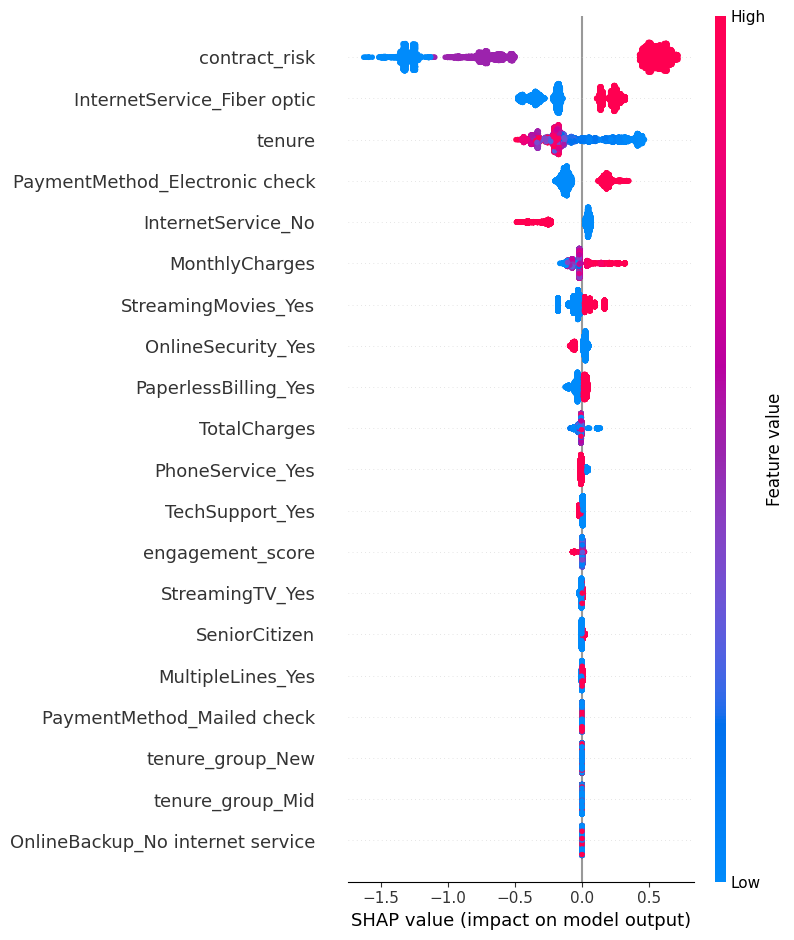

In [17]:
shap.summary_plot(shap_values, X)

Bar plot

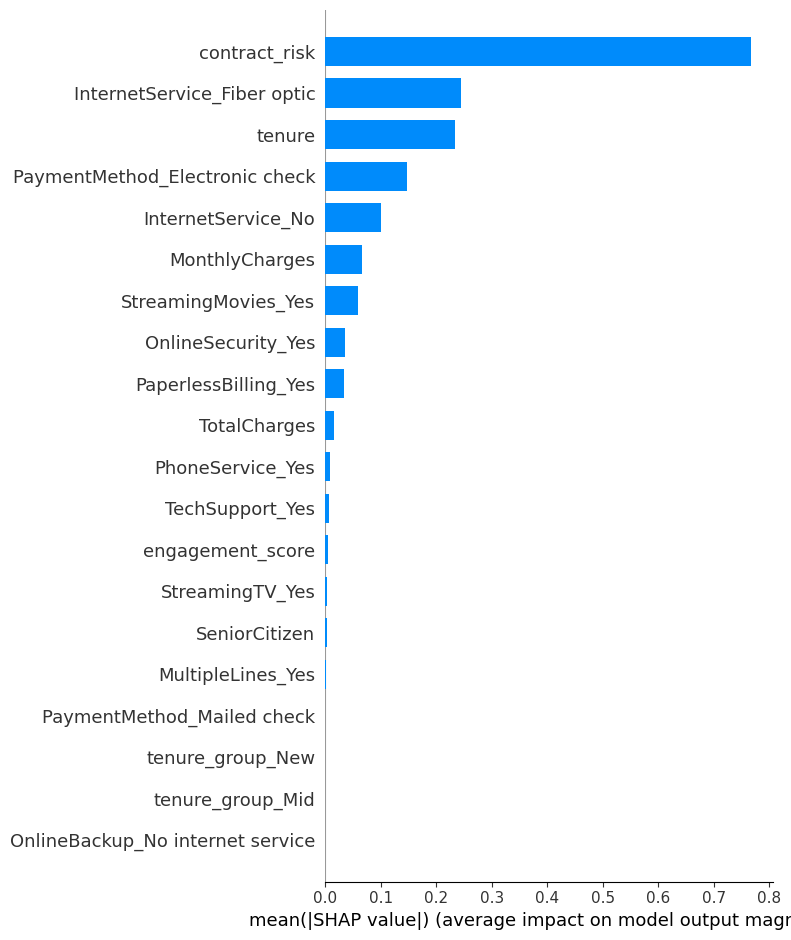

In [18]:
shap.summary_plot(shap_values, X, plot_type="bar")

SINGLE CUSTOMER

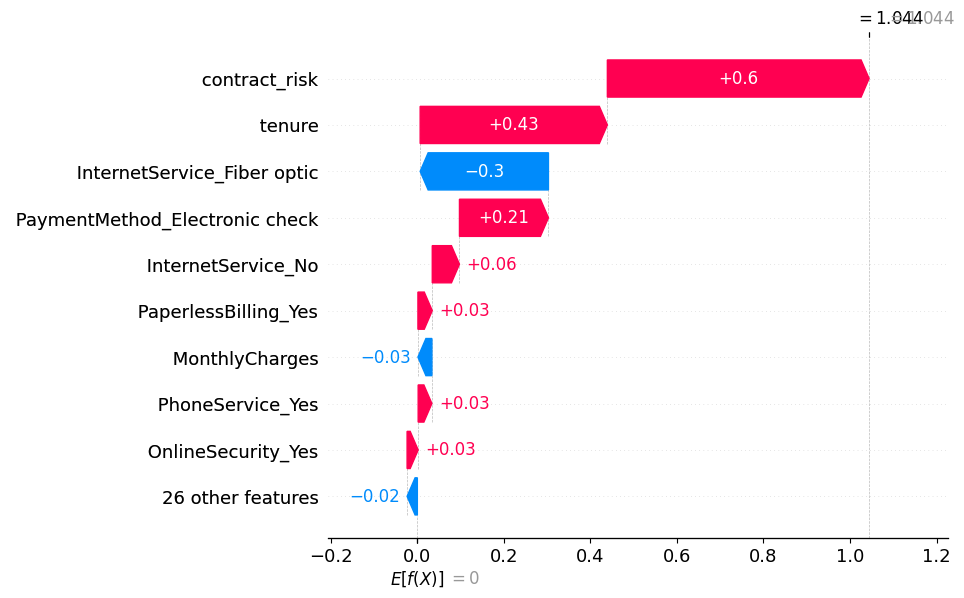

In [19]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    X.iloc[0]
)